# Task 05 — Machine Learning Model Development

The objective of this stage is to train and compare multiple classification algorithms for predicting whether a patient will be readmitted within 30 days.

The following models will be evaluated:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. XGBoost

The models will be evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = pd.read_csv("../data/smartcare_ai_dataset_1000.csv")

data["room_type"] = data["room_type"].fillna("Unknown")

data["appointment_date"] = pd.to_datetime(
    data["appointment_date"],
    errors="coerce"
)

data["appointment_year"] = data["appointment_date"].dt.year
data["appointment_month"] = data["appointment_date"].dt.month
data["appointment_day"] = data["appointment_date"].dt.day
data["appointment_dayofweek"] = data["appointment_date"].dt.dayofweek

model_data = data.drop(columns=[
    "appointment_date",
    "record_id",
    "patient_id",
    "no_show",
    "disease_risk_level"
])

X = model_data.drop(columns=["readmitted_30_days"])
y = model_data["readmitted_30_days"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
preprocessor = joblib.load("../models/preprocessor.joblib")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training:", X_train_processed.shape)
print("Testing:", X_test_processed.shape)

Training: (800, 65)
Testing: (200, 65)


In [6]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [7]:
y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [8]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [9]:
y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [10]:
svm_model = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_processed,
    y_train
)

print("SVM trained successfully!")


SVM trained successfully!


c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [11]:
y_pred_svm = svm_model.predict(X_test_processed)
y_prob_svm = svm_model.predict_proba(X_test_processed)[:, 1]

print("SVM predictions generated!")

SVM predictions generated!


In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [13]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [15]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [16]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        y_pred_svm,
        y_prob_svm
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb,
        y_prob_xgb
    )
)

In [17]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.885,0.718750,0.901961,0.800000,0.941571
1,Random Forest,0.895,0.708333,1.000000,0.829268,0.941440
2,SVM,0.895,0.708333,1.000000,0.829268,0.936571
3,XGBoost,0.890,0.723077,0.921569,0.810345,0.939466


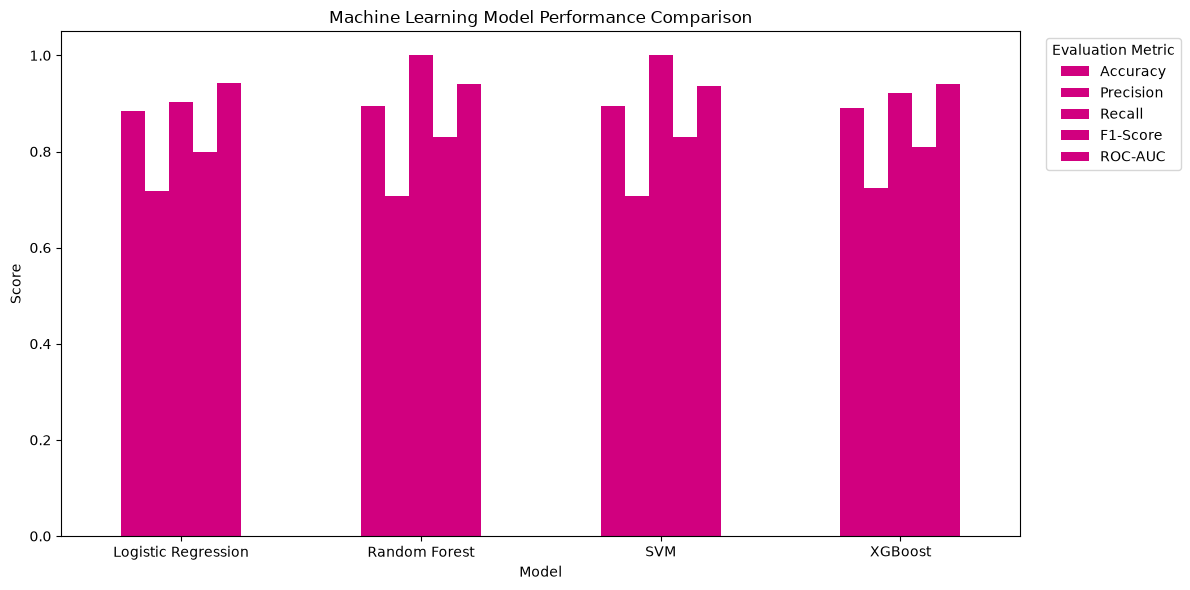

In [18]:
import matplotlib.pyplot as plt
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color="#D1007F"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 5.4 Initial Model Comparison

Four classification models were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Random Forest and Support Vector Machine achieved the highest accuracy of 89.5% and a recall of 100%, indicating that they successfully identified all readmitted patients in the test set.

Logistic Regression achieved the highest ROC-AUC of 0.9416, indicating strong overall discrimination between the two classes. XGBoost achieved the highest precision at 72.31% while maintaining a recall of 92.16%.

Although Random Forest and SVM currently provide the highest accuracy and recall, the final model will not be selected based on a single metric. Further analysis, including confusion matrices, cross-validation, and hyperparameter tuning, will be performed before selecting the final SmartCare AI model.

In [19]:
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

for name, predictions in models_predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, predictions))


Logistic Regression
[[131  18]
 [  5  46]]

Random Forest
[[128  21]
 [  0  51]]

SVM
[[128  21]
 [  0  51]]

XGBoost
[[131  18]
 [  4  47]]


In [20]:
for name, predictions in models_predictions.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions))


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       149
           1       0.72      0.90      0.80        51

    accuracy                           0.89       200
   macro avg       0.84      0.89      0.86       200
weighted avg       0.90      0.89      0.89       200


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90      0.90       200


SVM
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90

In [21]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr))

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf))

print("=" * 60)
print("SVM")
print("=" * 60)
print(classification_report(y_test, y_pred_svm))

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print(classification_report(y_test, y_pred_xgb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       149
           1       0.72      0.90      0.80        51

    accuracy                           0.89       200
   macro avg       0.84      0.89      0.86       200
weighted avg       0.90      0.89      0.89       200

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90      0.90       200

SVM
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90   

In [22]:
for name, predictions in models_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(cm)


Logistic Regression
[[131  18]
 [  5  46]]

Random Forest
[[128  21]
 [  0  51]]

SVM
[[128  21]
 [  0  51]]

XGBoost
[[131  18]
 [  4  47]]


# 5.5 Cross-Validation

Cross-validation is performed to evaluate the stability and generalization performance of each machine learning model. A 5-fold Stratified Cross-Validation approach is used to preserve the class distribution across all folds.

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [24]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "CV Accuracy": [
        cross_val_score(logistic_model, X_train_processed, y_train,
                        cv=cv, scoring="accuracy").mean(),

        cross_val_score(random_forest_model, X_train_processed, y_train,
                        cv=cv, scoring="accuracy").mean(),

        cross_val_score(svm_model, X_train_processed, y_train,
                        cv=cv, scoring="accuracy").mean(),

        cross_val_score(xgb_model, X_train_processed, y_train,
                        cv=cv, scoring="accuracy").mean()
    ]
})

cv_results

c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\sklearn\svm\_base.py:239: Future

,Model,CV Accuracy
0,Logistic Regression,0.9225
1,Random Forest,0.9300
2,SVM,0.9300
3,XGBoost,0.9250


In [25]:
from sklearn.model_selection import GridSearchCV

rf_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [26]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=rf_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 12, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [27]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best F1 Score:
0.8785815637738572


In [28]:
best_rf = grid_search.best_estimator_

best_rf.fit(
    X_train_processed,
    y_train
)

y_pred_best = best_rf.predict(X_test_processed)
y_prob_best = best_rf.predict_proba(X_test_processed)[:, 1]

In [29]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90      0.90       200



In [30]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1-Score:
0.8785815637738572


In [31]:
print("\nTuned Random Forest Classification Report")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred_best
))


Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      0.86      0.92       149
           1       0.71      1.00      0.83        51

    accuracy                           0.90       200
   macro avg       0.85      0.93      0.88       200
weighted avg       0.93      0.90      0.90       200



In [32]:
tuned_rf_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1-Score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best)
}

tuned_rf_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.895,
 'Precision': 0.7083333333333334,
 'Recall': 1.0,
 'F1-Score': 0.8292682926829268,
 'ROC-AUC': 0.938149756546914}

In [33]:
final_results = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_rf_results])
    ],
    ignore_index=True
)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.885,0.718750,0.901961,0.800000,0.941571
1,Random Forest,0.895,0.708333,1.000000,0.829268,0.941440
2,SVM,0.895,0.708333,1.000000,0.829268,0.936571
3,XGBoost,0.890,0.723077,0.921569,0.810345,0.939466
4,Tuned Random Forest,0.895,0.708333,1.000000,0.829268,0.938150


In [34]:
final_results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.895,0.708333,1.000000,0.829268,0.941440
4,Tuned Random Forest,0.895,0.708333,1.000000,0.829268,0.938150
2,SVM,0.895,0.708333,1.000000,0.829268,0.936571
3,XGBoost,0.890,0.723077,0.921569,0.810345,0.939466
0,Logistic Regression,0.885,0.718750,0.901961,0.800000,0.941571


# 6.1 Final Model Selection

Five model configurations were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Random Forest achieved an accuracy of 89.5%, recall of 100%, F1-score of 82.93%, and ROC-AUC of 94.14%. It successfully identified all 51 patients in the test set who were actually readmitted within 30 days.

The tuned Random Forest model produced the same accuracy, precision, recall, and F1-score as the original Random Forest model, while its ROC-AUC was slightly lower. Therefore, additional tuning did not provide an improvement over the original Random Forest configuration.

Logistic Regression achieved the highest ROC-AUC at 94.16%, while XGBoost achieved the highest precision at 72.31%. However, Random Forest provided the strongest overall balance for the project's objective, particularly because of its 100% recall.

Therefore, the original Random Forest model was selected as the final candidate model for the SmartCare AI readmission prediction system.

In [35]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\rusir\OneDrive\Desktop\SmartCare-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


In [36]:
explainer = shap.TreeExplainer(random_forest_model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [37]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(200, 65, 2)


In [38]:
print("Test data shape:", X_test_processed.shape)

Test data shape: (200, 65)


In [39]:
print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP is a list")
    for i, value in enumerate(shap_values):
        print(f"Class {i} shape:", value.shape)
else:
    print("SHAP shape:", shap_values.shape)

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (200, 65, 2)


In [40]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 65
['numerical__age' 'numerical__waiting_days'
 'numerical__previous_appointments'
 'numerical__missed_previous_appointments' 'numerical__admitted'
 'numerical__length_of_stay_days' 'numerical__previous_admissions'
 'numerical__systolic_bp' 'numerical__diastolic_bp'
 'numerical__blood_sugar_mg_dl' 'numerical__cholesterol_mg_dl'
 'numerical__bmi' 'numerical__lab_tests_count'
 'numerical__treatments_count' 'numerical__consultation_fee_lkr'
 'numerical__room_charge_lkr' 'numerical__lab_charge_lkr'
 'numerical__medicine_charge_lkr' 'numerical__total_bill_lkr'
 'numerical__appointment_year' 'numerical__appointment_month'
 'numerical__appointment_day' 'numerical__appointment_dayofweek'
 'categorical__gender_Female' 'categorical__gender_Male'
 'categorical__blood_group_A+' 'categorical__blood_group_A-'
 'categorical__blood_group_AB+' 'categorical__blood_group_AB-'
 'categorical__blood_group_B+' 'categorical__blood_group_B-'
 'categorical__blood_group_O+' 'categorical_

In [41]:
shap_class_1 = shap_values[:, :, 1]

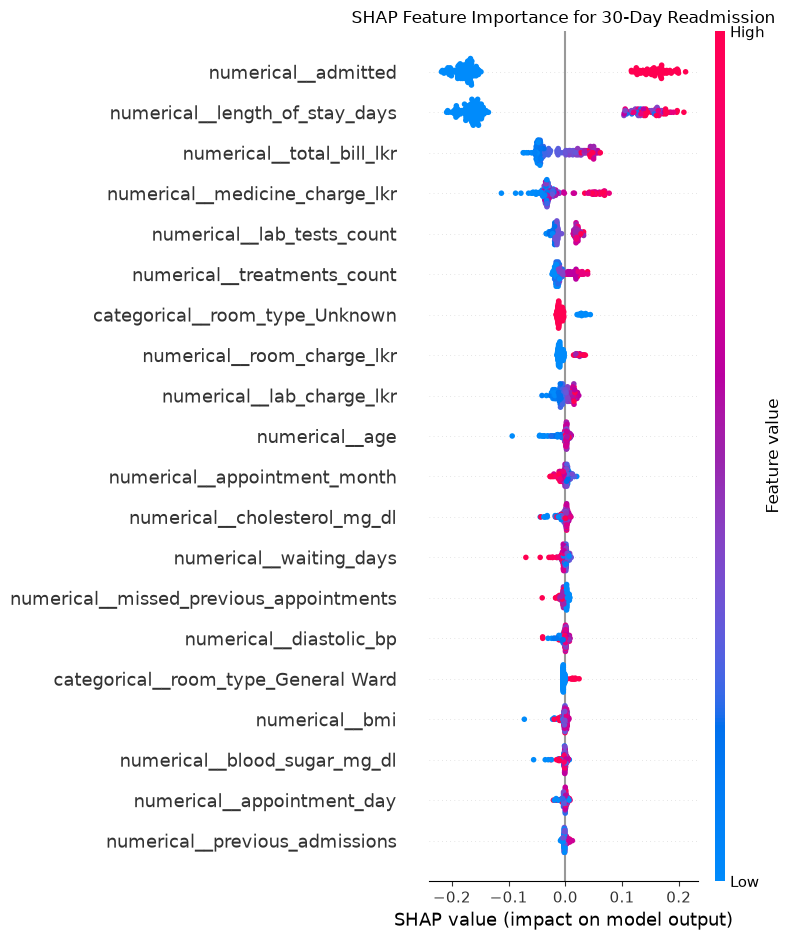

In [42]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_class_1,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance for 30-Day Readmission")
plt.tight_layout()
plt.show()

🔴 Red → higher feature value
🔵 Blue → lower feature value

And the position along the horizontal axis indicates whether that feature pushes the prediction toward or away from 30-day readmission.

In [43]:
joblib.dump(
    random_forest_model,
    "../models/smartcare_random_forest.pkl"
)

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


In [44]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.joblib"
)

print("Preprocessing pipeline saved successfully!")

Preprocessing pipeline saved successfully!


In [45]:
print(final_results.sort_values(by="F1-Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1        Random Forest     0.895   0.708333  1.000000  0.829268  0.941440
4  Tuned Random Forest     0.895   0.708333  1.000000  0.829268  0.938150
2                  SVM     0.895   0.708333  1.000000  0.829268  0.936571
3              XGBoost     0.890   0.723077  0.921569  0.810345  0.939466
0  Logistic Regression     0.885   0.718750  0.901961  0.800000  0.941571
